In [2]:
from google.colab import files
uploaded = files.upload()

Saving IT_Support_Tickets.xlsx to IT_Support_Tickets (1).xlsx


In [3]:
import pandas as pd

df = pd.read_excel("IT_Support_Tickets.xlsx")

df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Channel,Description,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes
0,TKT00001,2025-04-25 00:00,2025-04-26 08:00,Resolved,Low,Problem,Access,India,1,Cluster_3,...,Chat,Synthetic IT support ticket generated for anal...,security,Office365,1,1,LATAM,Mobile,macOS,Issue resolved after troubleshooting.
1,TKT00002,2025-06-09 06:00,2025-06-09 20:00,Resolved,High,Request,Integration,India,24,Cluster_15,...,Portal,Synthetic IT support ticket generated for anal...,security,ERP,1,0,EMEA,Mobile,Windows,Issue resolved after troubleshooting.
2,TKT00003,2025-08-27 03:00,2025-08-28 15:00,Open,Medium,Request,Bug,Germany,22,Cluster_9,...,Chat,Synthetic IT support ticket generated for anal...,email,Office365,5,1,NaN,Laptop,Linux,Issue resolved after troubleshooting.
3,TKT00004,2025-02-02 10:00,2025-02-03 21:00,Pending,High,Incident,Email,Singapore,21,Cluster_15,...,Chat,Synthetic IT support ticket generated for anal...,security,VPN,3,1,EMEA,Tablet,Windows,Issue resolved after troubleshooting.
4,TKT00005,2025-02-18 03:00,2025-02-21 12:00,In Progress,Low,Request,Access,UAE,17,Cluster_9,...,Chat,Synthetic IT support ticket generated for anal...,vpn,VPN,1,2,EMEA,Laptop,macOS,Issue resolved after troubleshooting.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              10000 non-null  object 
 1   Created_Date           10000 non-null  object 
 2   Resolution_Date        10000 non-null  object 
 3   Status                 10000 non-null  object 
 4   Priority               10000 non-null  object 
 5   Ticket_Type            10000 non-null  object 
 6   Category               10000 non-null  object 
 7   Country                10000 non-null  object 
 8   Cluster_ID             10000 non-null  int64  
 9   Cluster_Name           10000 non-null  object 
 10  Similarity_Score       10000 non-null  float64
 11  Similarity_Level       10000 non-null  object 
 12  First_Response_Date    10000 non-null  object 
 13  Assigned_Agent         10000 non-null  object 
 14  Team                   10000 non-null  object 
 15  SLA

In [5]:
df.isnull().sum()

,0
Ticket_ID,0
Created_Date,0
Resolution_Date,0
Status,0
Priority,0
Ticket_Type,0
Category,0
Country,0
Cluster_ID,0
Cluster_Name,0


In [6]:
df.shape

(10000, 30)

In [7]:
df["Ticket_Type"].value_counts()

,count
Ticket_Type,
Request,3421
Problem,3310
Incident,3269


In [8]:
df["Priority"].value_counts()


,count
Priority,
Medium,2551
Critical,2498
High,2481
Low,2470


In [9]:
df["Category"].value_counts()

,count
Category,
Software,1309
Security,1278
Hardware,1274
Integration,1256
Bug,1236
Access,1228
Email,1213
Network,1206


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()


In [12]:
df.dtypes

,0
Ticket_ID,object
Created_Date,object
Resolution_Date,object
Status,object
Priority,object
Ticket_Type,object
Category,object
Country,object
Cluster_ID,int64
Cluster_Name,object


In [13]:
date_columns = [
    "Created_Date",
    "Resolution_Date",
    "First_Response_Date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [14]:
df.dtypes

,0
Ticket_ID,object
Created_Date,datetime64[ns]
Resolution_Date,datetime64[ns]
Status,object
Priority,object
Ticket_Type,object
Category,object
Country,object
Cluster_ID,int64
Cluster_Name,object


In [15]:
df.isnull().sum()

,0
Ticket_ID,0
Created_Date,0
Resolution_Date,0
Status,0
Priority,0
Ticket_Type,0
Category,0
Country,0
Cluster_ID,0
Cluster_Name,0


In [16]:
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].fillna("Unknown")

In [17]:
df.isnull().sum()

,0
Ticket_ID,0
Created_Date,0
Resolution_Date,0
Status,0
Priority,0
Ticket_Type,0
Category,0
Country,0
Cluster_ID,0
Cluster_Name,0


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
date_columns = ["Created_Date", "Resolution_Date", "First_Response_Date"]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [20]:
df["Resolution_Duration"] = (
    df["Resolution_Date"] - df["Created_Date"]
).dt.days

In [21]:
df[["Created_Date", "Resolution_Date", "Resolution_Duration"]].head()

,Created_Date,Resolution_Date,Resolution_Duration
0,2025-04-25 00:00:00,2025-04-26 08:00:00,1
1,2025-06-09 06:00:00,2025-06-09 20:00:00,0
2,2025-08-27 03:00:00,2025-08-28 15:00:00,1
3,2025-02-02 10:00:00,2025-02-03 21:00:00,1
4,2025-02-18 03:00:00,2025-02-21 12:00:00,3


In [22]:
priority_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Critical": 4
}

df["Priority_Score"] = df["Priority"].map(priority_map)

In [23]:
df[["Priority", "Priority_Score"]].head()

,Priority,Priority_Score
0,Low,1
1,High,3
2,Medium,2
3,High,3
4,Low,1


In [24]:
df.to_csv("Cleaned_IT_Support_Tickets.csv", index=False)

In [25]:
import matplotlib.pyplot as plt

In [26]:
import pandas as pd

df = pd.read_csv("Cleaned_IT_Support_Tickets.csv")

**MODULE3**

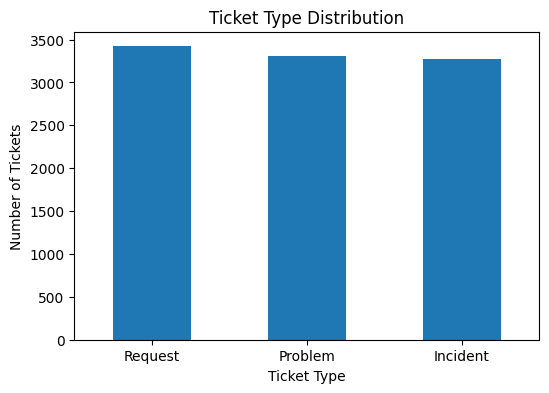

In [27]:
ticket_type = df["Ticket_Type"].value_counts()

plt.figure(figsize=(6,4))
ticket_type.plot(kind="bar")
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.show()

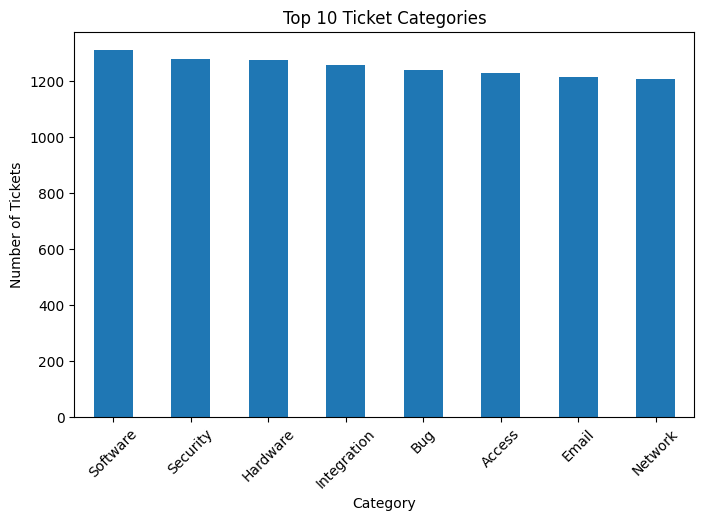

In [28]:
top_categories = df["Category"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_categories.plot(kind="bar")
plt.title("Top 10 Ticket Categories")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

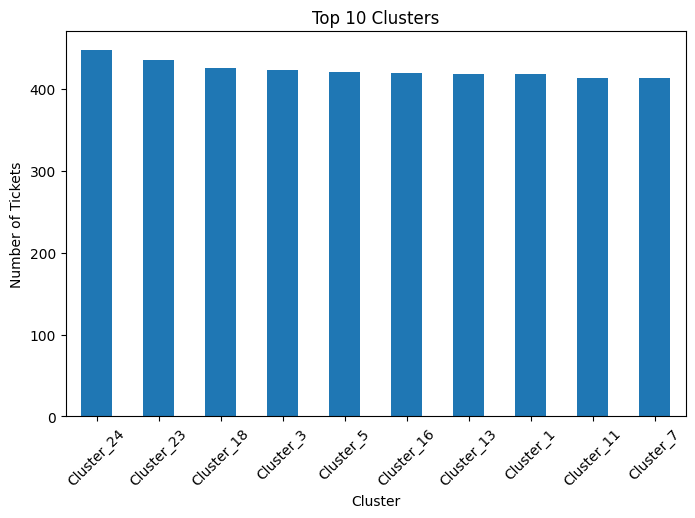

In [29]:
top_clusters = df["Cluster_Name"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_clusters.plot(kind="bar")
plt.title("Top 10 Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

In [39]:
queue_map = {
    "Access": "Technical Support",
    "Integration": "Application Support",
    "Bug": "Development Team",
    "Email": "Email Support",
    "Security": "Security Team",
    "Network": "Network Support",
    "Software": "Software Support",
    "Hardware": "Hardware Support"
}

df["Queue"] = df["Category"].map(queue_map)

In [40]:
df[["Category", "Queue"]].head(10)

,Category,Queue
0,Access,Technical Support
1,Integration,Application Support
2,Bug,Development Team
3,Email,Email Support
4,Access,Technical Support
5,Bug,Development Team
6,Integration,Application Support
7,Security,Security Team
8,Security,Security Team
9,Network,Network Support


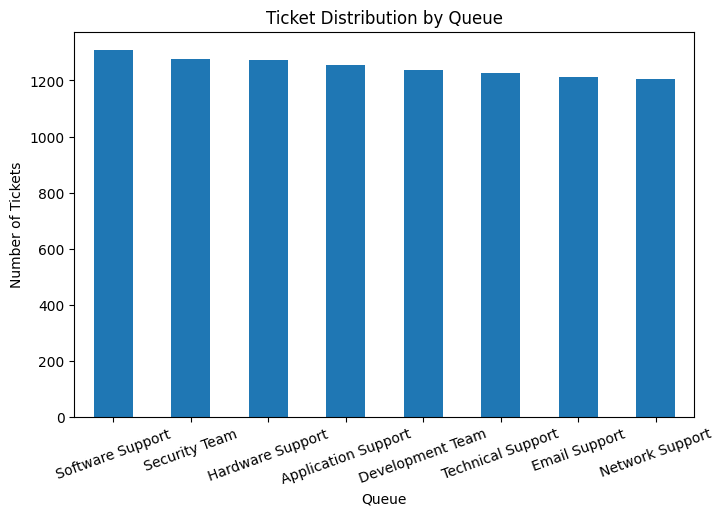

In [41]:
import matplotlib.pyplot as plt

df["Queue"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Ticket Distribution by Queue")
plt.xlabel("Queue")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)
plt.show()

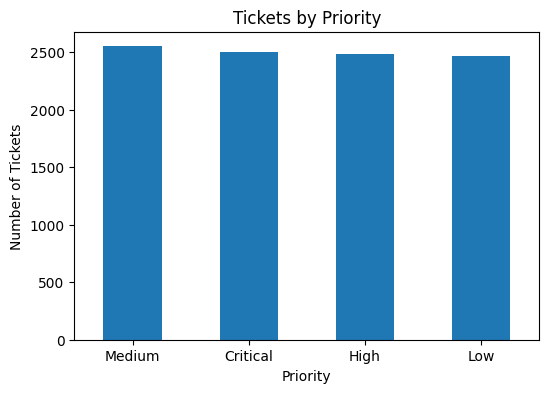

In [30]:
priority = df["Priority"].value_counts()

plt.figure(figsize=(6,4))
priority.plot(kind="bar")
plt.title("Tickets by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.show()

**MODULE4**

In [31]:
print(df.columns.tolist())

['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority', 'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name', 'Similarity_Score', 'Similarity_Level', 'First_Response_Date', 'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code', 'Department', 'Customer_ID', 'Channel', 'Description', 'Tags', 'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region', 'Device_Type', 'Operating_System', 'Resolution_Notes', 'Resolution_Duration', 'Priority_Score']


In [32]:
df.columns

Index(['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority',
       'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name',
       'Similarity_Score', 'Similarity_Level', 'First_Response_Date',
       'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code',
       'Department', 'Customer_ID', 'Channel', 'Description', 'Tags',
       'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region',
       'Device_Type', 'Operating_System', 'Resolution_Notes',
       'Resolution_Duration', 'Priority_Score'],
      dtype='object')

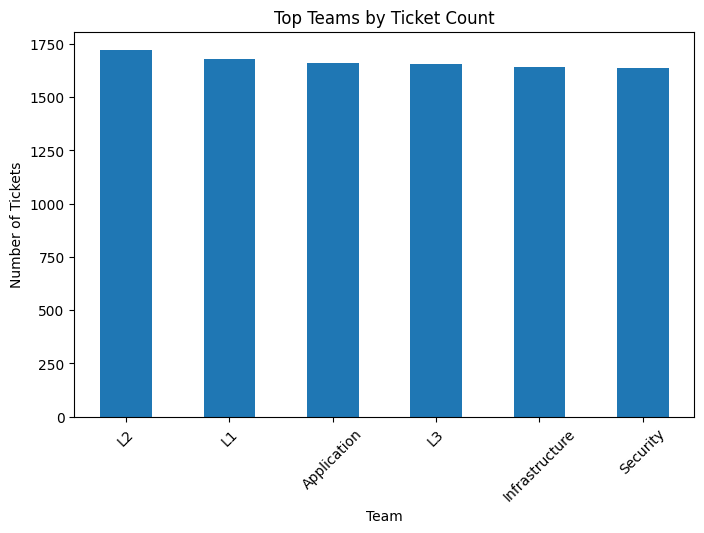

In [33]:
team = df["Team"].value_counts().head(10)

plt.figure(figsize=(8,5))
team.plot(kind="bar")
plt.title("Top Teams by Ticket Count")
plt.xlabel("Team")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

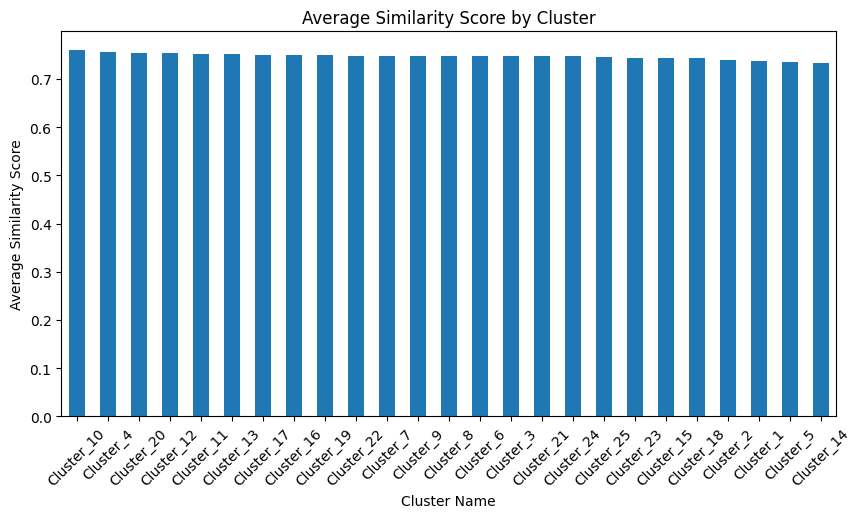

In [34]:
cluster_similarity = df.groupby("Cluster_Name")["Similarity_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
cluster_similarity.plot(kind="bar")
plt.title("Average Similarity Score by Cluster")
plt.xlabel("Cluster Name")
plt.ylabel("Average Similarity Score")
plt.xticks(rotation=45)
plt.show()

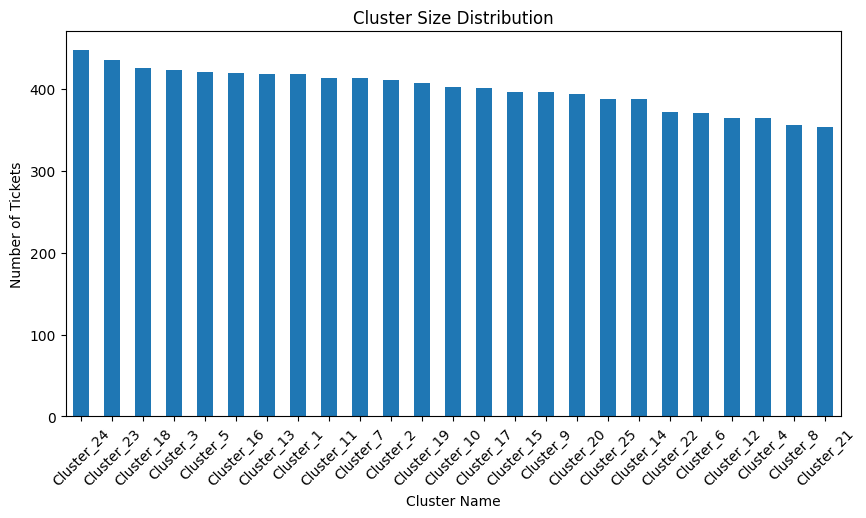

In [35]:
cluster_size = df["Cluster_Name"].value_counts()

plt.figure(figsize=(10,5))
cluster_size.plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

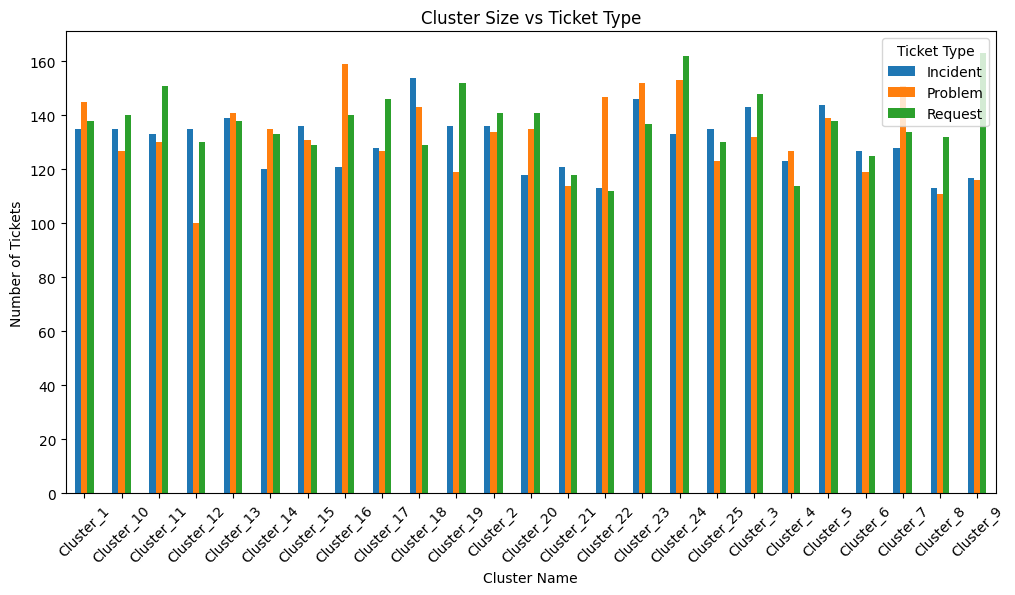

In [36]:
cluster_issue = pd.crosstab(df["Cluster_Name"], df["Ticket_Type"])

cluster_issue.plot(kind="bar", figsize=(12,6))
plt.title("Cluster Size vs Ticket Type")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.legend(title="Ticket Type")
plt.show()

<Figure size 1200x600 with 0 Axes>

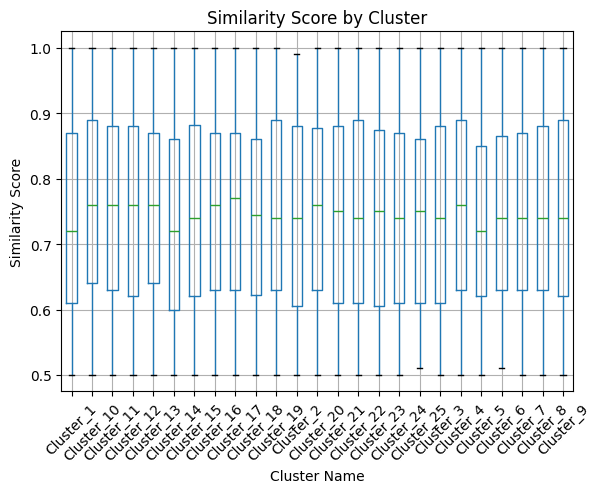

In [37]:
plt.figure(figsize=(12,6))

df.boxplot(column="Similarity_Score", by="Cluster_Name", rot=45)

plt.title("Similarity Score by Cluster")
plt.suptitle("")
plt.xlabel("Cluster Name")
plt.ylabel("Similarity Score")
plt.show()

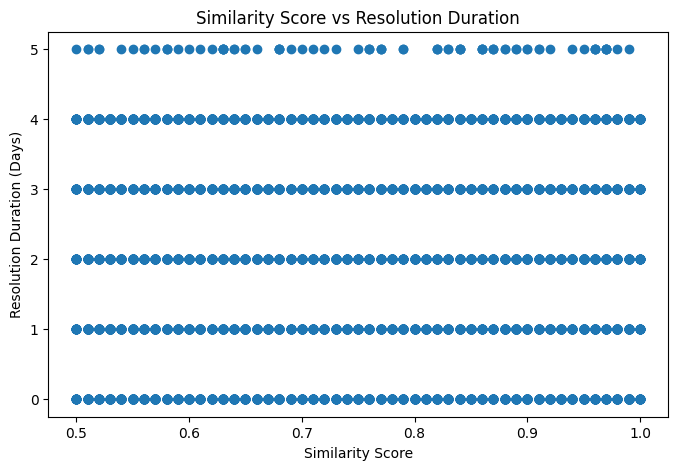

In [38]:
plt.figure(figsize=(8,5))

plt.scatter(df["Similarity_Score"], df["Resolution_Duration"])

plt.title("Similarity Score vs Resolution Duration")
plt.xlabel("Similarity Score")
plt.ylabel("Resolution Duration (Days)")
plt.show()